# CNN Decoder Implementation

This file defines, trains, and saves a CNN decoder model

Refs:
https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html


In [1]:
%pip install -r ../../requirements.txt


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Imports and Config

In [2]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

In [3]:
d = 7
random_seed = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## Load dataset
Notebook generate_train_data should be ran prior to this.
dataset is saved in data/ folder

In [5]:
data_dir = Path("./data")
data_path = Path(data_dir, f"rotated_surface_code_distance_{d}.npz")
metadata_path = Path(data_dir, f"rotated_surface_code_distance_{d}_metadata.json")

data = np.load(data_path)
X = data["X"]
y = data["y"]

with open(metadata_path, "r") as f:
    metadata = json.load(f)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("logical error rate:", y.mean())
print("metadata:", metadata)

X shape: (100000, 22, 8, 8)
y shape: (100000,)
logical error rate: 0.03192
metadata: {'dataset_name': 'rotated_surface_code_distance_7', 'task': 'surface_code:rotated_memory_z', 'distance': 7, 'rounds': 21, 'physical_error_rate': 0.0001, 'shots': 100000, 'num_detectors': 1008, 'num_observables': 1, 'input_shape': [22, 8, 8], 'time_slices': 22, 'height': 8, 'width': 8, 'unique_x_coords': [0.0, 0.0, 0.0, 2.0, 2.0, 2.0, 4.0, 4.0, 4.0, 6.0, 6.0, 6.0, 8.0, 8.0, 8.0, 10.0, 10.0, 10.0, 12.0, 12.0, 12.0, 14.0, 14.0, 14.0, 2.0, 6.0, 10.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 4.0, 8.0, 12.0, 2.0, 6.0, 10.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 0.0, 2.0, 4.0, 6.0,

In [6]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

print("X_tensor shape:", X_tensor.shape)
print("y_tensor shape:", y_tensor.shape)

X_tensor shape: torch.Size([100000, 22, 8, 8])
y_tensor shape: torch.Size([100000, 1])


## Split dataset

In [ ]:
dataset = TensorDataset(X_tensor, y_tensor)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

training_data, val_data = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(random_seed))


batch_size = 64

train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

## CNN Class
Input shape of [batch,channels,height,width]
channels = syndrome time slices
height = detector grid
width = detector grid

In [8]:
# Multiple layers of convolutions, then flatten, then fc layers
class CNN(nn.Module):
    def __init__(self, input_shape):
        super(CNN, self).__init__()
        self.cnn_layers = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * input_shape[1] * input_shape[2], 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.cnn_layers(x)
        return x

## Init model, loss function

In [ ]:
input_shape = X_tensor.shape[1:]
model = CNN(input_shape).to(device)

learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

targets = y_tensor.view(-1)

# Class weighting derived from https://www.geeksforgeeks.org/deep-learning/handling-class-imbalance-in-pytorch/
# class 0 = no logical flip
# class 1 = logical flip
class_sample_count = torch.tensor(
    [(targets == 0).sum().item(),
     (targets == 1).sum().item()],
     dtype=torch.float32,
     device=device)

# rare classes get larger weights
samples_weight = 1.0 / class_sample_count

negative_weight = samples_weight[0]
positive_weight = samples_weight[1]

pos_weight = torch.tensor(
    [positive_weight / negative_weight],
    dtype=torch.float32,
    device=device)

loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("input_shape:", input_shape)
print("negative samples:", int(class_sample_count[0].item()))
print("positive samples:", int(class_sample_count[1].item()))
print("positive weight:", pos_weight.item())

input_shape: torch.Size([22, 8, 8])
negative samples: 96808
positive samples: 3192
positive weight: 30.328319549560547


## Train and Validate

Following pytorch docs https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html

In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)

    # PyTorch docs: set the model to training mode
    model.train()

    for batch, (X, y) in enumerate(dataloader):
        X = X.to(device)
        y = y.to(device)

        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss_value = loss.item()
            current = batch * batch_size + len(X)
            print(f"loss: {loss_value:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # set model to eval
    model.eval()

    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    test_loss = 0
    correct = 0
    
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)

            pred = model(X)
            test_loss += loss_fn(pred, y).item()

            probabilities = torch.sigmoid(pred)
            predicted_labels = (probabilities >= 0.5).float()

            correct += (predicted_labels == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size

    print(
        f"Test Error: \n"
        f" Accuracy: {(100 * correct):>0.1f}%, "
        f"Avg loss: {test_loss:>8f} \n"
    )

    return test_loss, correct

## Training

In [ ]:
epochs = 10

train_losses = []
test_losses = []
test_accuracies = []

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}\n-------------------------------")

    train_loop(train_dataloader, model, loss_function, optimizer)

    test_loss, test_accuracy = test_loop(
        val_dataloader,
        model,
        loss_function
    )

    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

print("Done training loop")

Epoch 1
-------------------------------
loss: 0.004722  [   32/80000]
loss: 0.003035  [ 3232/80000]
loss: 0.000002  [ 6432/80000]
loss: 0.003608  [ 9632/80000]
loss: 0.007785  [12832/80000]
loss: 0.092008  [16032/80000]
loss: 0.000318  [19232/80000]
loss: 0.000067  [22432/80000]
loss: 0.000247  [25632/80000]
loss: 0.002038  [28832/80000]
loss: 0.000263  [32032/80000]
loss: 0.003529  [35232/80000]
loss: 0.035942  [38432/80000]
loss: 0.000035  [41632/80000]
loss: 0.000049  [44832/80000]
loss: 0.003423  [48032/80000]
loss: 0.001228  [51232/80000]
loss: 0.002997  [54432/80000]
loss: 0.000507  [57632/80000]
loss: 0.000019  [60832/80000]
loss: 0.000068  [64032/80000]
loss: 0.000774  [67232/80000]
loss: 0.000018  [70432/80000]
loss: 0.007499  [73632/80000]
loss: 0.000384  [76832/80000]
Test Error: 
 Accuracy: 99.3%, Avg loss: 0.223250 

Epoch 2
-------------------------------
loss: 0.004954  [   32/80000]
loss: 0.000180  [ 3232/80000]
loss: 0.000001  [ 6432/80000]
loss: 0.134923  [ 9632/80000

## Training Plots

TODO: Adjust this to keep track of metrics besides just loss. Maybe keep track of positive and negative labels because of small weights

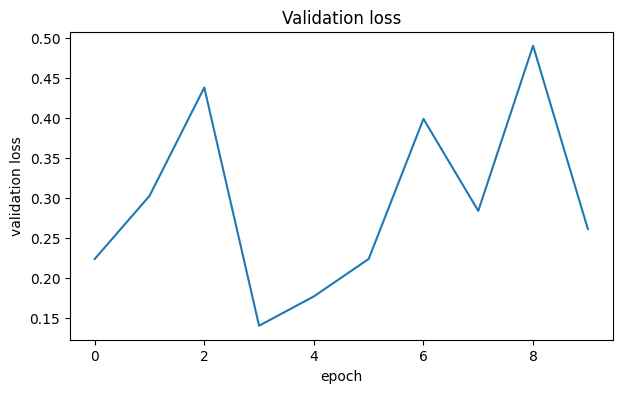

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(test_losses)
plt.xlabel("epoch")
plt.ylabel("validation loss")
plt.title("validation loss")
plt.show()

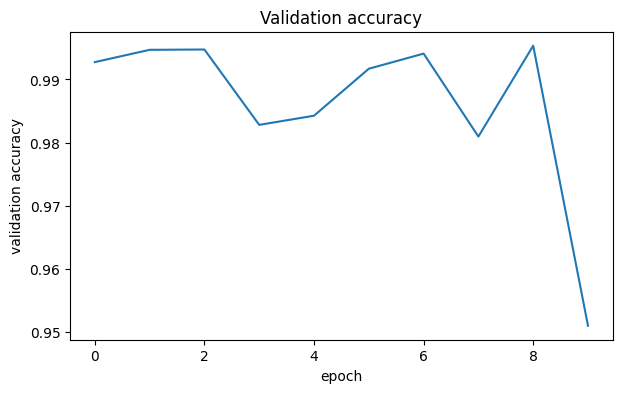

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(test_accuracies)
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.title("validation accuracy")
plt.show()

## Save model

In [20]:
model_dir = Path("./models")
model_dir.mkdir(exist_ok=True)

model_path = model_dir / f"cnn_decoder_distance_{d}.pth"

torch.save(model.state_dict(), model_path)

print("Saved model to:", model_path)

Saved model to: models/cnn_decoder_distance_7.pth
